In [1]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/PHD/Fall 2025/Deep Learning/iris_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and the file exists in your Google Drive.")
    df = None # Set df to None to avoid errors in subsequent steps


Dataset loaded successfully.


## Exploratory Data Analysis (EDA)

Let's start by looking at the first few rows, checking the data types, and getting some descriptive statistics.

In [2]:
if df is not None:
    print("First 5 rows of the dataset:")
    display(df.head())

    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe())

First 5 rows of the dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Distribution of the target variable:


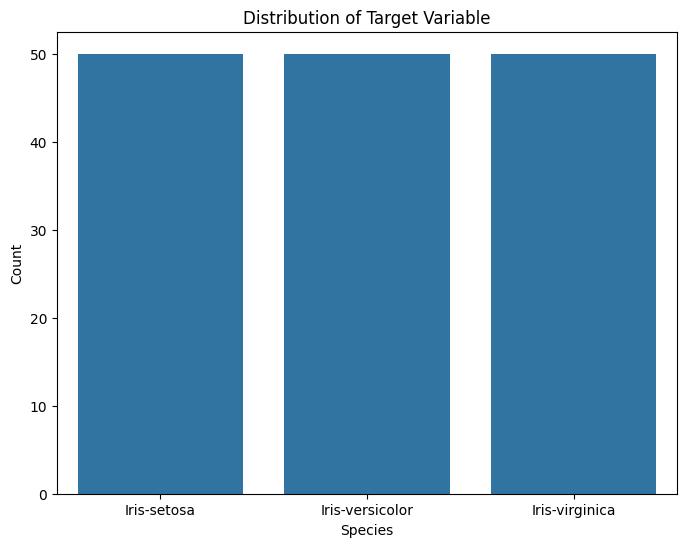


Pairplot of features:


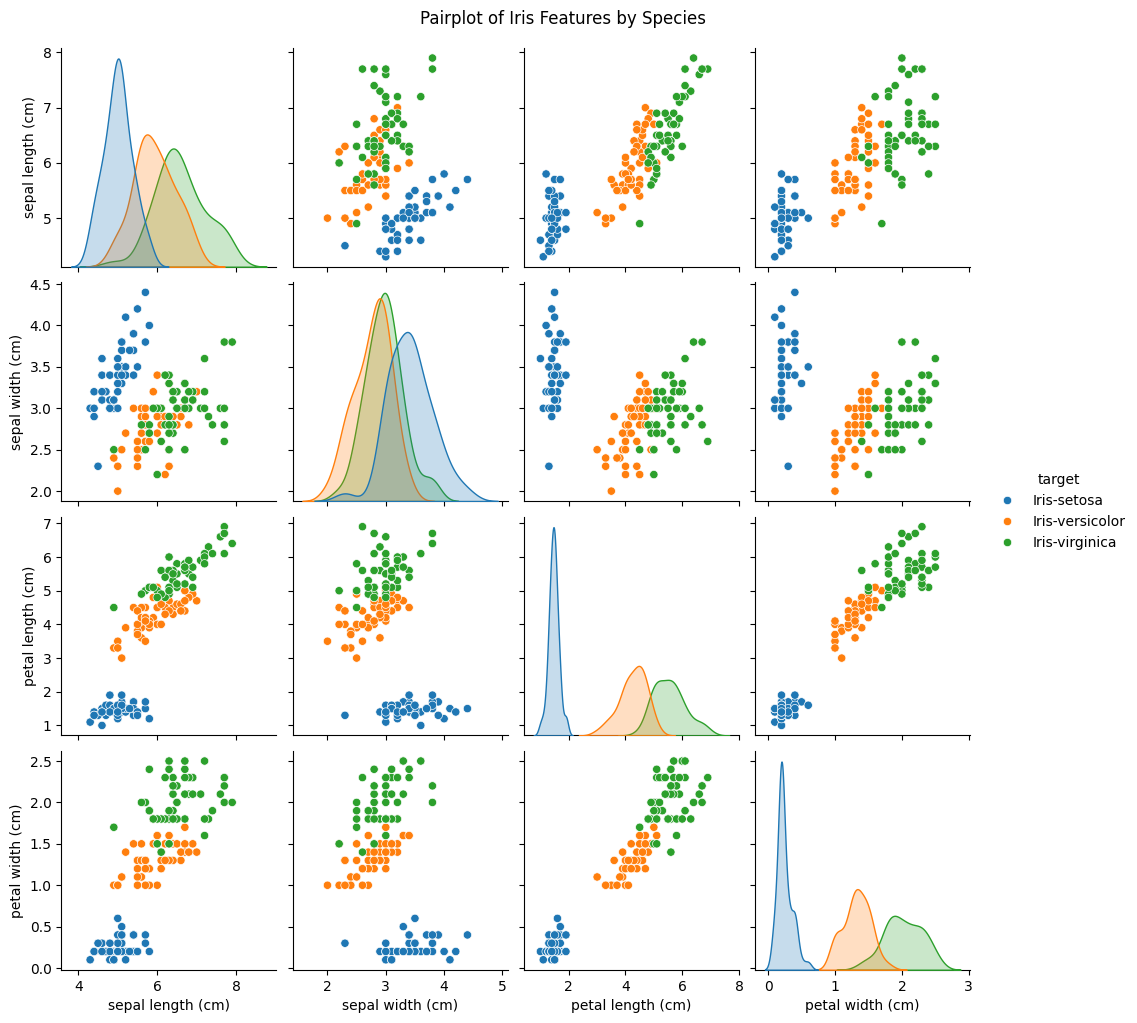

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Check the distribution of the target variable
    print("\nDistribution of the target variable:")
    plt.figure(figsize=(8, 6))
    sns.countplot(x=df.columns[-1], data=df)
    plt.title('Distribution of Target Variable')
    plt.xlabel('Species')
    plt.ylabel('Count')
    plt.show()

    # Pairplot to visualize relationships between features
    print("\nPairplot of features:")
    sns.pairplot(df, hue=df.columns[-1])
    plt.suptitle('Pairplot of Iris Features by Species', y=1.02) # Adjust suptitle position
    plt.show()

## Training a RandomForest Classifier

Now, let's prepare the data, split it into training and testing sets, and train a RandomForest Classifier.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os
import joblib # For saving the model

if df is not None:
    # Separate features (X) and target (y)
    X = df.iloc[:, :-1] # All columns except the last one as features
    y = df.iloc[:, -1]  # The last column as the target

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

    print("Data split into training and testing sets.")
    print(f"Training set size: {len(X_train)} samples")
    print(f"Testing set size: {len(X_test)} samples")

    # Initialize and train the RandomForestClassifier
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    print("RandomForestClassifier trained successfully.")

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\nModel Accuracy: {accuracy:.4f}")

    # Save the model
    model_dir = '/content/drive/MyDrive/PHD/Fall 2025/Deep Learning/Model'
    os.makedirs(model_dir, exist_ok=True)
    model_path = os.path.join(model_dir, 'random_forest_iris_model.joblib')
    joblib.dump(model, model_path)

    print(f"Model saved to '{model_path}'")
else:
    print("Cannot proceed with model training and saving as the dataset was not loaded.")

Data split into training and testing sets.
Training set size: 105 samples
Testing set size: 45 samples
RandomForestClassifier trained successfully.

Model Accuracy: 0.8889
Model saved to '/content/drive/MyDrive/PHD/Fall 2025/Deep Learning/Model/random_forest_iris_model.joblib'
